# Imports

In [1]:
# Purpose: standard imports and project path setup
import os, sys, json, itertools, math, random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch
from torch.utils.data import DataLoader
from typing import Dict, Tuple


# Add project root so `import src...` works if notebook in notebooks/
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path: sys.path.append(ROOT)

from src import preprocessing as preprocessing
from src import features as features
from src import models as models
from src import training as training
from src import visualisation as viz

print("Torch:", torch.__version__)

e:\Python\Bicycle_Traffic_Flow_GNN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.8.0+cu128


# Configuration

In [2]:
# Purpose: define config, seeds, and (optionally) exam periods for stratification
cfg = preprocessing.Config(
    time_granularity="15min",
    H_in=12, H_out=12,
    batch_size=64, lr=1e-3,
    max_epochs=30, patience=8,
    seed=42, use_exog=True,
    gcn_type="cheb", cheb_K=3, nblocks=2, hidden=32, dropout=0.12,
    lambda_lap=1e-3
)
debug = False

# grid search settings
feature_grid_search = False          # takes a long time if True
hyperparam_optimisation = False      # takes a long time if True

features.set_seed(cfg.seed)

# Define exam ranges (example — adjust to your calendar)
exam_ranges = [
    ("2025-01-20","2025-01-31"),
    ("2025-04-07","2025-04-17"),
]
holiday_dates = [
    ("2025-01-01","2025-01-05"),
    ("2025-02-01","2025-02-09"),
    ("2025-04-18","2025-04-21"),
]


In [3]:
if debug:
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # sync CUDA for clearer stacktraces
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA available:", torch.cuda.is_available(), "device in cfg:", cfg.device)

#### Graph Network

In [4]:
# Nodes
nodes = ['A','B','C','D','E','G','H','I','J','K','L','M','N','O','P']

# Example coordinates in (x, y). Replace with your true values (meters or canvas units).
pos = {
    'A': (0, 10), 'B': (5, 10),
    'C': (0, 7),  'D': (5, 7),
    'E': (0, 4), 'G': (9, 4),
    'H': (-3, 1), 'I': (0, 1), 'J': (5, 1), 'K': (9, 1), 'L': (12, 1),
    'M': (0, -2), 'N': (5, -2), 'O': (9, -2),
    'P': (5, -5)
}

# Physical undirected links
physical_edges = [
    ('A','B'),        # no sensor
    ('A','C'),
    ('C','E'),
    ('B','D'),
    ('D','J'),
    ('C','D'),        # no sensor
    ('D','G'),        # no sensor
    ('G','K'),
    ('K','O'),
    ('H','I'),
    ('I','J'),
    ('J','K'),
    ('K','L'),
    ('E','I'),
    ('J','N'),        # no sensor
    ('N','P'),
    ('I','M'),
    ('M','N'),        # no sensor
    ('N','O')         # no sensor
]

# Edges without sensors (undirected listing). Both directions will be masked.
no_sensor_undir = {('A','B'), ('M','N'), ('N','O'), ('D','G'), ('J','N'), ('C','D')}

# Map each (sensor_id|element_name) to its BASE direction (u->v).
# count_in goes to (u->v); count_out goes to (v->u).
sensor_to_edge: Dict[str, Tuple[str,str]] = {
    "TUD_SBX01|Line 0": ("D", "B"),
    "TUD_SPX18|Line 0": ("A", "C"),
    "TUD_SBX22|Line 0": ("E", "C"),
    "TUD_SBXN6A|Line 2": ("D", "J"),
    "TUD_SBXN6A|Line 0": ("J", "K"),
    "TUD_SPX23|Line 0": ("I", "E"),
    "TUD_SBX25|Line 2": ("I", "H"),
    "TUD_SBX26|Line 0": ("I", "M"),
    "TUD_SPX24|Line 0": ("J", "I"),
    "TUD_SBX07-MULTI|Line 1": ("G", "K"),
    "TUD_SBX07-MULTI|Line 2": ("K", "L"),
    "TUD_SBX07-MULTI|Line 3": ("O", "K"),
    "TUD_SBXN13|Line 0": ("P", "N"),
}

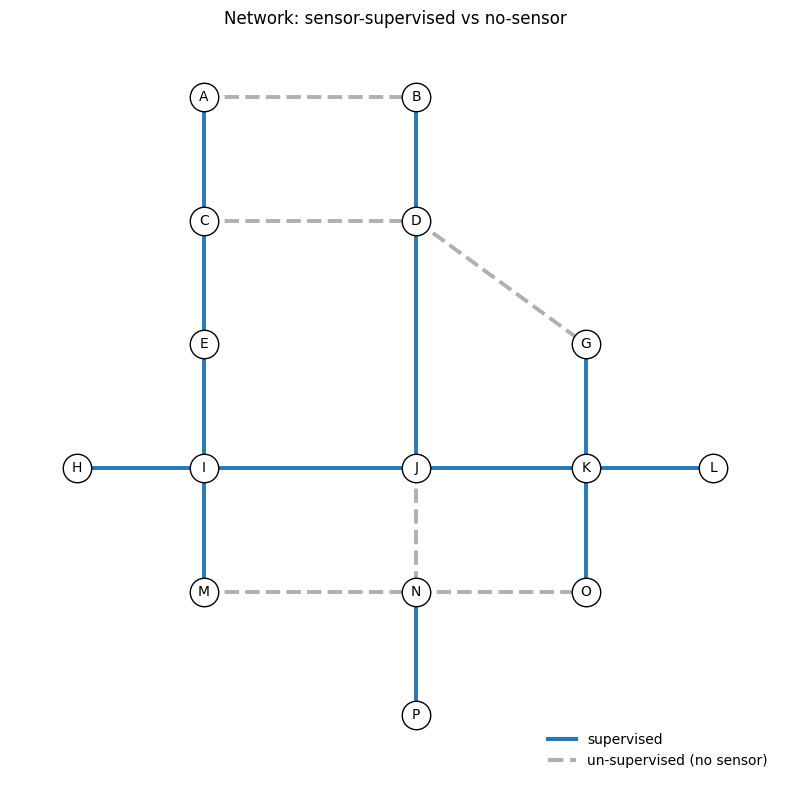

In [5]:
directed_edges = preprocessing.undir_to_dir(physical_edges)
edge_index = {e:i for i,e in enumerate(directed_edges)}
index_edge = {i:e for e,i in edge_index.items()}

A_line = preprocessing.build_line_graph_adjacency(directed_edges, allow_uturn=False)
# choose ONE normalization policy; we keep row-normalized with self-loops once
A_hat = preprocessing.row_normalize_with_self_loops(A_line)

network_cfg = preprocessing.NetworkConfig(
    nodes=nodes, pos=pos, physical_edges=physical_edges, no_sensor_undir=no_sensor_undir,
    sensor_to_edge=sensor_to_edge, directed_edges=directed_edges,
    edge_index=edge_index, index_edge=index_edge, a_line=A_line, a_hat=A_hat
)

viz.draw_sensor_coverage_network(network_cfg, title="Network: sensor-supervised vs no-sensor")

# Data loading and Preprocessing 

In [6]:
# Purpose: Build data, exogenous, masks, and gap-aware loaders using src functions

from src import training as training

csv_paths = [
    "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv",
    "data/smartcameras_line--2025-02-01T03-01-00--2025-03-01T03-01-00--tud_project--bvtmix.csv",
    "data/smartcameras_line--2025-03-01T03-01-00--2025-04-01T03-01-00--tud_project--a93fyx.csv",
    "data/smartcameras_line--2025-04-01T03-01-00--2025-05-01T03-01-00--tud_project--henvbs.csv",
]
nc_paths = [
    "data/davis-TUD-EWI_Roof_Electrical_Engineering_202501.nc",
    "data/davis-TUD-EWI_Roof_Electrical_Engineering_202502.nc",
    "data/davis-TUD-EWI_Roof_Electrical_Engineering_202503.nc",
    "data/davis-TUD-EWI_Roof_Electrical_Engineering_202504.nc",
]

data = preprocessing.build_data_and_loaders(
    csv_paths=csv_paths,
    nc_paths=nc_paths,
    cfg=cfg,
    network_cfg=network_cfg,
    exam_ranges=exam_ranges,
    holiday_ranges=holiday_dates,
)

times      = data["times"]
X, M, T, E = data["X"], data["M"], data["T"], data["E"]
weather_df = data["weather_df"]
exog       = data["exog"]
cats       = data["cats"]
flags      = data["flags"]
masks      = data["masks"]
loaders    = data["loaders"]

print(f"T={T}, E={E}, exog={exog.shape}")
print("weather cols:", None if weather_df is None else list(weather_df.columns))
print("batches:", {k: len(v) for k,v in loaders.items()})
print("lags:", data["lags"])

viz.print_split_day_summary(times, masks,
                            holiday_ranges=holiday_dates,
                            exam_ranges=exam_ranges)


T=11525, E=38, exog=(11525, 38, 19)
weather cols: ['temperature', 'wind_mps', 'wind_gust_speed', 'rain_mm', 'rain_mm_h']
batches: {'train': 115, 'val': 22, 'test': 21}
lags: {'L_24h': 96, 'L_7d': 672}
Days total: 121
train days= 85 | weekend=29.4% holiday=15.3% exam=18.8%
val   days= 18 | weekend=27.8% holiday=16.7% exam=16.7%
test  days= 18 | weekend=22.2% holiday=11.1% exam=22.2%


# Feature grid search

In [7]:
# # === Powerset grid over explicit extras (lags ALWAYS on; no renaming) ===
# import itertools, time, dataclasses
# import numpy as np, pandas as pd, torch
# from src import features, training

# # --- show weather columns once ---
# if 'weather_df' not in globals() or weather_df is None or weather_df.empty:
#     print("weather_df is missing or empty; only calendar flags will be considered.")
# else:
#     print("weather_df columns:", list(weather_df.columns))

# # --- context_df with EXACT columns you want ---
# context_df = pd.DataFrame(index=pd.DatetimeIndex(times))

# wanted_weather = ["temperature", "rain_mm", "rain_mm_h", "wind_mps", "wind_gust_speed"]
# present_weather = []
# missing_weather = wanted_weather[:]
# if ('weather_df' in globals()) and (weather_df is not None) and (not weather_df.empty):
#     present_weather = [c for c in wanted_weather if c in weather_df.columns]
#     missing_weather = [c for c in wanted_weather if c not in weather_df.columns]
#     if present_weather:
#         context_df = pd.concat([context_df, weather_df[present_weather].reindex(context_df.index)], axis=1)

# wanted_flags = ["is_weekend","is_exam","is_holiday"]
# present_flags = [c for c in wanted_flags if c in flags.columns]
# context_df = pd.concat([context_df, flags[present_flags].reindex(context_df.index)], axis=1)

# print("Using weather columns:", present_weather)
# if missing_weather: print("Not found (skipped):", missing_weather)
# print("Using calendar flags:", present_flags)

# # --- candidates ---
# candidate_cols = [c for c in (present_weather + present_flags) if c in context_df.columns]
# print(f"Candidate features (N={len(candidate_cols)}): {candidate_cols}")

# # --- lag steps & adjacency ---
# L_24h = features.steps_for_hours(cfg.time_granularity, 24)
# L_7d  = features.steps_for_hours(cfg.time_granularity, 24*7)
# A_bin = (network_cfg.a_line > 0).astype(np.float32)

# def build_exog_from_subset(selected_cols):
#     ctx = context_df[selected_cols] if selected_cols else pd.DataFrame(index=context_df.index)
#     exog = features.add_exogenous(
#         times=pd.DatetimeIndex(times), E=E, config=cfg,
#         weather_df=ctx, calendar_flags=None,
#         X=X, M=M, A_bin=A_bin,
#         use_graph_fill=True,
#         lags_self=(1,2,3, L_24h, L_7d),
#         lags_neigh=(1,2),
#         ema_alpha=0.7, fill_weights=(0.7,0.3,0.0),
#         Xhat_prev=None
#     ).astype("float32")
#     return np.nan_to_num(exog, nan=0.0, posinf=0.0, neginf=0.0)

# def run_one_combo(selected_cols, budget_epochs=20):
#     ex = build_exog_from_subset(selected_cols)
#     loaders = training.make_loaders_gapaware(pd.DatetimeIndex(times), X, M, ex, cfg, masks, shuffle_train=True)
#     Fin = ex.shape[2] + 1
#     model = training.build_gnn(E, Fin, cfg.H_out, network_cfg.a_hat, cfg)
#     cfg_try = dataclasses.replace(cfg, max_epochs=budget_epochs)
#     model = training.train_model(model, loaders, cfg_try, epoch_hook=None, A_bin=A_bin,
#                                  show_epoch_bar=False, leave_bar=False)  # mute per-epoch bars
#     val_metrics  = training.evaluate(model, loaders["val"],  cfg_try.device)
#     test_metrics = training.evaluate(model, loaders["test"], cfg_try.device)
#     return float(val_metrics["MAE"]), float(test_metrics["MAE"])

# # --- full powerset (includes empty set) with ONE tqdm ---
# all_combs = [tuple(comb) for r in range(0, len(candidate_cols)+1)
#              for comb in itertools.combinations(candidate_cols, r)]
# print(f"Total settings to evaluate: {len(all_combs)} (2^{len(candidate_cols)})")

# rows = []
# best_val = float("inf")        # <-- initialize!
# best_label = "(none)"          # <-- initialize!
# t0 = time.time()

# for comb in tqdm(all_combs, desc="Feature grid", leave=False):
#     label = "(none)" if len(comb)==0 else "+".join(comb)
#     mae_val, mae_test = run_one_combo(list(comb), budget_epochs=20)
#     rows.append({
#         "features_on": label, "combo": comb, "k_on": len(comb),
#         "gnn_val_MAE": mae_val, "gnn_test_MAE": mae_test,
#     })
#     if mae_val < best_val:
#         best_val, best_label = mae_val, label
#         tqdm.write(f"best so far: {best_label} -> {best_val:.4f}")

#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

# res_df = pd.DataFrame(rows).sort_values(["gnn_val_MAE","k_on"]).reset_index(drop=True)
# print(f"Grid done over {len(res_df)} settings in {time.time()-t0:.1f}s")
# display(res_df.head(10))


In [8]:
# === Feature selection: full powerset grid (if enabled) OR preset features (if disabled) ===
import itertools, time, dataclasses
import numpy as np, pandas as pd, torch
from tqdm.auto import tqdm
from src import features, training

# ---- 0) Build context_df from EXACT columns you care about (no renaming) ----
if 'weather_df' not in globals() or weather_df is None or weather_df.empty:
    print("weather_df is missing or empty; only calendar flags will be considered.")
else:
    print("weather_df columns:", list(weather_df.columns))

context_df = pd.DataFrame(index=pd.DatetimeIndex(times))

wanted_weather = ["temperature", "rain_mm", "rain_mm_h", "wind_mps", "wind_gust_speed"]
present_weather = []
if ('weather_df' in globals()) and (weather_df is not None) and (not weather_df.empty):
    present_weather = [c for c in wanted_weather if c in weather_df.columns]
    if present_weather:
        context_df = pd.concat([context_df,
                                weather_df[present_weather].reindex(context_df.index)],
                               axis=1)

wanted_flags = ["is_weekend","is_exam","is_holiday"]
present_flags = [c for c in wanted_flags if c in flags.columns]
context_df = pd.concat([context_df, flags[present_flags].reindex(context_df.index)], axis=1)

print("Using weather columns:", present_weather)
print("Using calendar flags:", present_flags)

candidate_cols = [c for c in (present_weather + present_flags) if c in context_df.columns]
print(f"Candidate features (N={len(candidate_cols)}): {candidate_cols}")

# ---- 1) Lags & adjacency (always on) + exog builder ----
L_24h = features.steps_for_hours(cfg.time_granularity, 24)
L_7d  = features.steps_for_hours(cfg.time_granularity, 24*7)
A_bin = (network_cfg.a_line > 0).astype(np.float32)

def build_exog_from_subset(selected_cols):
    """Selected extras from context_df; add_exogenous appends lags & TOD/DOW."""
    ctx = context_df[selected_cols] if selected_cols else pd.DataFrame(index=context_df.index)
    exog = features.add_exogenous(
        times=pd.DatetimeIndex(times), E=E, config=cfg,
        weather_df=ctx,              # only the chosen extras (weather+flags by name)
        calendar_flags=None,         # avoid double-adding flags
        X=X, M=M, A_bin=A_bin,
        use_graph_fill=True,
        lags_self=(1,2,3, L_24h, L_7d),
        lags_neigh=(1,2),
        ema_alpha=0.7, fill_weights=(0.7,0.3,0.0),
        Xhat_prev=None
    ).astype("float32")
    return np.nan_to_num(exog, nan=0.0, posinf=0.0, neginf=0.0)

def run_one_combo(selected_cols, budget_epochs=20):
    ex = build_exog_from_subset(selected_cols)
    loaders = training.make_loaders_gapaware(pd.DatetimeIndex(times), X, M, ex, cfg, masks, shuffle_train=True)
    Fin = ex.shape[2] + 1
    model = training.build_gnn(E, Fin, cfg.H_out, network_cfg.a_hat, cfg)
    cfg_try = dataclasses.replace(cfg, max_epochs=budget_epochs)
    # mute per-epoch bars during the grid
    model = training.train_model(model, loaders, cfg_try, epoch_hook=None, A_bin=A_bin,
                                 show_epoch_bar=False, leave_bar=False)
    val = training.evaluate(model, loaders["val"],  cfg_try.device)["MAE"]
    test = training.evaluate(model, loaders["test"], cfg_try.device)["MAE"]
    return float(val), float(test)

# ---- 2) Toggle: run the grid OR pick a preset ----
if feature_grid_search:
    # Full powerset (includes empty set)
    all_combs = [tuple(comb) for r in range(0, len(candidate_cols)+1)
                 for comb in itertools.combinations(candidate_cols, r)]
    print(f"Total settings to evaluate: {len(all_combs)} (2^{len(candidate_cols)})")

    rows = []
    best_val = float("inf")
    best_label = "(none)"
    t0 = time.time()

    for comb in tqdm(all_combs, desc="Feature grid", leave=False):
        label = "(none)" if len(comb)==0 else "+".join(comb)
        mae_val, mae_test = run_one_combo(list(comb), budget_epochs=20)
        rows.append({
            "features_on": label,
            "combo": comb,
            "k_on": len(comb),
            "gnn_val_MAE": mae_val,
            "gnn_test_MAE": mae_test,
        })
        if mae_val < best_val:
            best_val, best_label = mae_val, label
            tqdm.write(f"best so far: {best_label} -> {best_val:.4f}")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    res_df = pd.DataFrame(rows).sort_values(["gnn_val_MAE","k_on"]).reset_index(drop=True)
    print(f"Grid done over {len(res_df)} settings in {time.time()-t0:.1f}s")
    display(res_df.head(10))

    best_combo = list(res_df.iloc[0]["combo"])  # list of feature names
    exog_best  = build_exog_from_subset(best_combo)

else:
    # PRESET path: keep downstream variables consistent
    preset_features = ['temperature', 'rain_mm_h', 'wind_gust_speed', 'is_weekend', 'is_exam']  # <- edit to your preferred default
    best_combo = [c for c in preset_features if c in context_df.columns]
    print("Feature grid disabled. Using preset features:", best_combo if best_combo else "(none)")
    exog_best  = build_exog_from_subset(best_combo)

    # Minimal res_df so later cells (that expect res_df) still work
    res_df = pd.DataFrame([{
        "features_on": "(preset)" if best_combo else "(none)",
        "combo": tuple(best_combo),
        "k_on": len(best_combo),
        "gnn_val_MAE": np.nan,
        "gnn_test_MAE": np.nan,
    }])


weather_df columns: ['temperature', 'wind_mps', 'wind_gust_speed', 'rain_mm', 'rain_mm_h']
Using weather columns: ['temperature', 'rain_mm', 'rain_mm_h', 'wind_mps', 'wind_gust_speed']
Using calendar flags: ['is_weekend', 'is_exam', 'is_holiday']
Candidate features (N=8): ['temperature', 'rain_mm', 'rain_mm_h', 'wind_mps', 'wind_gust_speed', 'is_weekend', 'is_exam', 'is_holiday']
Feature grid disabled. Using preset features: ['temperature', 'rain_mm_h', 'wind_gust_speed', 'is_weekend', 'is_exam']


In [9]:
# === Single-feature MAE + average-in-combos; Top-5 ===
import pandas as pd
pd.set_option("display.max_colwidth", None)  # no truncation

def mae_only_feature(df, f):
    if f == "(none)":
        row = df[df["k_on"]==0].head(1)
    else:
        row = df[(df["k_on"]==1) & (df["combo"].apply(lambda c: (len(c)==1 and c[0]==f)))]
    return float(row["gnn_val_MAE"].iloc[0]) if len(row) else float("nan")

def mae_avg_when_included(df, f):
    if f == "(none)":
        row = df[df["k_on"]==0]
        return float(row["gnn_val_MAE"].mean()) if len(row) else float("nan")
    sel = df[df["combo"].apply(lambda c: f in c)]
    return float(sel["gnn_val_MAE"].mean()) if len(sel) else float("nan")

rows = []
rows.append({
    "feature": "(none)",
    "only_val_MAE": mae_only_feature(res_df, "(none)"),
    "avg_val_MAE_when_included": mae_avg_when_included(res_df, "(none)")
})
for f in candidate_cols:
    rows.append({
        "feature": f,
        "only_val_MAE": mae_only_feature(res_df, f),
        "avg_val_MAE_when_included": mae_avg_when_included(res_df, f),
    })
feature_table = pd.DataFrame(rows).sort_values("avg_val_MAE_when_included", ascending=True).reset_index(drop=True)
display(feature_table)

top5 = res_df.sort_values(["gnn_val_MAE","k_on"]).head(5)
display(top5[["features_on","k_on","gnn_val_MAE","gnn_test_MAE"]])

print(f"Evaluated {len(res_df)} combos out of {2**len(candidate_cols)} possible.")


,feature,only_val_MAE,avg_val_MAE_when_included
0,(none),NaN,NaN
1,temperature,NaN,NaN
2,rain_mm,NaN,NaN
3,rain_mm_h,NaN,NaN
4,wind_mps,NaN,NaN
5,wind_gust_speed,NaN,NaN
6,is_weekend,NaN,NaN
7,is_exam,NaN,NaN
8,is_holiday,NaN,NaN


,features_on,k_on,gnn_val_MAE,gnn_test_MAE
0,(preset),5,NaN,NaN


Evaluated 1 combos out of 256 possible.


# Grid search for hyperparameters

In [10]:
# # === Hyperparameter grid search using the BEST feature combo from previous block ===
# import itertools, dataclasses, copy, math, time
# import numpy as np, pandas as pd, torch
# from src import training

# # 0) Pull the best feature combo and build exog_best
# best_combo = list(res_df.iloc[0]["combo"])  # tuple -> list of feature names
# print("Best feature combo:", best_combo if best_combo else "(none)")

# exog_best = build_exog_from_subset(best_combo)
# A_bin = (network_cfg.a_line > 0).astype(np.float32)

# # 1) Build a hyperparameter space only with fields your cfg actually supports
# def has(name):
#     return hasattr(cfg, name)

# hp_space = {}

# # Model architecture
# if has("hidden"):    hp_space["hidden"]   = [32, 48, 64]
# if has("nblocks"):   hp_space["nblocks"]  = [2, 3]
# if has("dropout"):   hp_space["dropout"]  = [0.10, 0.20]
# if has("gcn_type"):  hp_space["gcn_type"] = ["gcn", "cheb"]  # keep safe; "cheb" likely unsupported
# # if has("cheb_K"):    hp_space["cheb_K"]   = [2, 3]   # only if you enable ChebGCN

# # Optimization / training
# # prefer "lr", fallback to "learning_rate"
# if has("lr") or has("learning_rate"):
#     hp_space["lr"] = [1e-3, 1e-4, 1e-5]
# if has("weight_decay") or has("wd"):
#     hp_space["weight_decay"] = [0.0, 1e-4]
# if has("batch_size"):
#     hp_space["batch_size"] = [64, 128]  # adjust if OOM
# if has("patience"):
#     hp_space["patience"] = [8, 12]

# # 2) Helpers to read/write cfg fields robustly
# def get_cfg(c, k, default=None):
#     if hasattr(c, k): return getattr(c, k)
#     # fallbacks
#     if k == "lr" and hasattr(c, "learning_rate"): return getattr(c, "learning_rate")
#     if k == "weight_decay" and hasattr(c, "wd"):  return getattr(c, "wd")
#     return default

# def set_cfg(c, k, v):
#     # dataclass -> use replace; otherwise setattr on a shallow copy
#     if dataclasses.is_dataclass(c):
#         # map alternate names
#         if k == "lr" and hasattr(c, "learning_rate"):
#             return dataclasses.replace(c, learning_rate=v)
#         if k == "weight_decay" and hasattr(c, "wd"):
#             return dataclasses.replace(c, wd=v)
#         kwargs = {k: v}
#         return dataclasses.replace(c, **kwargs)
#     else:
#         c2 = copy.copy(c)
#         if k == "lr" and hasattr(c2, "learning_rate"):
#             setattr(c2, "learning_rate", v)
#         elif k == "weight_decay" and hasattr(c2, "wd"):
#             setattr(c2, "wd", v)
#         else:
#             setattr(c2, k, v)
#         return c2

# # 3) Cartesian product over the hp space (preserves insertion order)
# keys = list(hp_space.keys())
# vals = [hp_space[k] for k in keys]
# combos = list(itertools.product(*vals)) if vals else [()]

# print(f"HP trials: {len(combos)} over {len(keys)} parameters ->", dict((k, len(hp_space[k])) for k in keys))

# def run_one_hp(cfg_base, exog, budget_epochs=20):
#     loaders = training.make_loaders_gapaware(pd.DatetimeIndex(times), X, M, exog, cfg_base, masks, shuffle_train=True)
#     Fin = exog.shape[2] + 1
#     model = training.build_gnn(E, Fin, cfg_base.H_out, network_cfg.a_hat, cfg_base)
#     # train with a small budget for fair comparison
#     cfg_try = dataclasses.replace(cfg_base, max_epochs=budget_epochs)
#     model = training.train_model(model, loaders, cfg_try, epoch_hook=None, A_bin=A_bin)
#     val = training.evaluate(model, loaders["val"], cfg_try.device)["MAE"]
#     test = training.evaluate(model, loaders["test"], cfg_try.device)["MAE"]
#     return float(val), float(test), model

# # 4) Grid search
# rows = []
# best = {"mae": float("inf"), "cfg": None, "test": float("inf")}
# t0 = time.time()

# for i, combo in enumerate(combos, 1):
#     cfg_try = cfg
#     desc = {}
#     for k, v in zip(keys, combo):
#         cfg_try = set_cfg(cfg_try, k, v)
#         desc[k] = v

#     print(f"[{i}/{len(combos)}] {desc}")
#     val_mae, test_mae, _ = run_one_hp(cfg_try, exog_best, budget_epochs=20)

#     rows.append({**desc, "val_MAE": val_mae, "test_MAE": test_mae})

#     if val_mae < best["mae"]:
#         best = {"mae": val_mae, "cfg": cfg_try, "test": test_mae}

#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

# hp_df = pd.DataFrame(rows).sort_values("val_MAE").reset_index(drop=True)
# print(f"HP grid finished in {time.time()-t0:.1f}s; trials={len(hp_df)}")
# display(hp_df.head(10))

# # 5) Best config summary + a new cfg object with the best params
# print("Best val MAE:", best["mae"], " | Test MAE:", best["test"])
# cfg_best = best["cfg"]
# cfg_best


In [11]:
# # Best feature combo from previous cell → build exogenous once


# best_combo = list(res_df.iloc[0]["combo"])
# print("Best feature combo:", best_combo if best_combo else "(none)")
# exog_best = build_exog_from_subset(best_combo)
# A_bin = (network_cfg.a_line > 0).astype(np.float32)

# # Search space
# hp_space = {
#     "cheb_K":       [2, 3],
#     "hidden":       [32, 48, 64],
#     "nblocks":      [2, 3],
#     "dropout":      [0.10, 0.20],
#     "lr":           [1e-3, 1e-4, 1e-5],
#     "weight_decay": [0.0, 1e-4],
#     # "batch_size":   [64, 128],
#     # "patience":     [8, 12],
#     "H_in":         [12, 24],
#     "H_out":        [12, 24],
# }

# # Build combinations
# keys = list(hp_space)
# vals = [hp_space[k] for k in keys]
# combos = [dict(zip(keys, v)) for v in itertools.product(*vals)]
# print(f"HP trials: {len(combos)}")

# def run_one_hp(cfg_base, exog, budget_epochs=20):
#     loaders = training.make_loaders_gapaware(pd.DatetimeIndex(times), X, M, exog, cfg_base, masks, shuffle_train=True)
#     Fin = exog.shape[2] + 1
#     model = training.build_gnn(E, Fin, cfg_base.H_out, network_cfg.a_hat, cfg_base)
#     # TRAIN: no epoch bar during grid
#     cfg_try = dataclasses.replace(cfg_base, max_epochs=budget_epochs)
#     model = training.train_model(model, loaders, cfg_try, epoch_hook=None, A_bin=A_bin,
#                                  show_epoch_bar=False, leave_bar=False)
#     val = training.evaluate(model, loaders["val"], cfg_try.device)["MAE"]
#     test = training.evaluate(model, loaders["test"], cfg_try.device)["MAE"]
#     return float(val), float(test)

# rows = []
# best_val, best_test, cfg_best = float("inf"), None, None
# t0 = time.time()
# pbar = tqdm(combos, desc="HP grid", leave=False)
# for hp in pbar:
#     cfg_try = dataclasses.replace(cfg, **hp)
#     val_mae, test_mae = run_one_hp(cfg_try, exog_best, budget_epochs=20)
#     rows.append({**hp, "val_MAE": val_mae, "test_MAE": test_mae})
#     if val_mae < best_val:
#         best_val, best_test, cfg_best = val_mae, test_mae, cfg_try
    
#     # tqdm.write(f"best so far: {best_val:.4f} (test: {best_test:.4f})")

#     pbar.set_postfix(best=f"{best_val:.3f}")
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()
# pbar.close()

# hp_df = pd.DataFrame(rows).sort_values("val_MAE").reset_index(drop=True)
# print(f"HP grid finished in {time.time()-t0:.1f}s; trials={len(hp_df)}")
# display(hp_df.head(10))
# print("Best val MAE:", best_val, " | Corresponding test MAE:", best_test)
# cfg_best

In [12]:
# === Hyperparameter grid: resumable + toggleable ===
import os, json, dataclasses, pandas as pd
from itertools import product
from tqdm.auto import tqdm

RESULTS_HP = "artifacts/hp_grid_results.csv"
os.makedirs(os.path.dirname(RESULTS_HP), exist_ok=True)


best_combo = list(res_df.iloc[0]["combo"])
print("Best feature combo:", best_combo if best_combo else "(none)")
exog_best = build_exog_from_subset(best_combo)
A_bin = (network_cfg.a_line > 0).astype(np.float32)

# Search space
hp_space = {
    "time_granularity": ["5min", "15min", "30min"],
    "cheb_K":           [2, 3],
    "hidden":           [32, 48, 64],
    "nblocks":          [2, 3],
    "dropout":          [0.10, 0.20],
    "lr":               [1e-3, 1e-4, 1e-5],
    "weight_decay":     [0.0, 1e-4],
    "patience":         [8, 12],
    "H_in":             [12, 24],
    "H_out":            [12, 24],
}

def run_one_hp(cfg_base, exog, budget_epochs=20):
    loaders = training.make_loaders_gapaware(pd.DatetimeIndex(times), X, M, exog, cfg_base, masks, shuffle_train=True)
    Fin = exog.shape[2] + 1
    model = training.build_gnn(E, Fin, cfg_base.H_out, network_cfg.a_hat, cfg_base)
    # TRAIN: no epoch bar during grid
    cfg_try = dataclasses.replace(cfg_base, max_epochs=budget_epochs)
    model = training.train_model(model, loaders, cfg_try, epoch_hook=None, A_bin=A_bin,
                                 show_epoch_bar=False, leave_bar=False)
    val = training.evaluate(model, loaders["val"], cfg_try.device)["MAE"]
    test = training.evaluate(model, loaders["test"], cfg_try.device)["MAE"]
    return float(val), float(test)

# --- Build combinations from hp_space (assumed defined above) ---
hp_keys = list(hp_space)
hp_vals = [hp_space[k] for k in hp_keys]
combos  = [dict(zip(hp_keys, v)) for v in product(*hp_vals)]
print(f"HP trials: {len(combos)}")

# --- helper: stable key for a combo row ---
def hp_key(d: dict) -> str:
    return json.dumps({k: d[k] for k in sorted(d)}, sort_keys=True)

# --- helper: map aliases (e.g. weight_decay -> wd) and drop unknown fields ---
from dataclasses import fields
_CFG_FIELDS = {f.name for f in fields(cfg)}
_ALIAS = {"weight_decay": "wd"}  # extend if needed
def dataclass_replace_known(c, updates: dict):
    mapped   = {(_ALIAS.get(k, k)): v for k, v in updates.items()}
    filtered = {k: v for k, v in mapped.items() if k in _CFG_FIELDS}
    return dataclasses.replace(c, **filtered)

if hyperparam_optimisation:
    # resume set
    if os.path.exists(RESULTS_HP):
        hp_prev = pd.read_csv(RESULTS_HP)
        tried = set(hp_prev["key"].tolist())
    else:
        tried = set()

    rows = []
    best_val  = float("inf")
    best_test = None
    cfg_best  = None

    pbar = tqdm(combos, desc="HP grid", leave=False)
    for hp in pbar:
        key = hp_key(hp)
        if key in tried:
            continue

        cfg_try = dataclass_replace_known(cfg, hp)
        try:
            val_mae, test_mae = run_one_hp(cfg_try, exog_best, budget_epochs=20)
        except RuntimeError as e:
            print("RuntimeError during HP trial with config:", hp)
            raise e

        rec = {**hp, "key": key, "val_MAE": val_mae, "test_MAE": test_mae}
        rows.append(rec)

        # append immediately (so we can resume after crashes)
        pd.DataFrame([rec]).to_csv(
            RESULTS_HP,
            mode=("a" if os.path.exists(RESULTS_HP) else "w"),
            header=not os.path.exists(RESULTS_HP),
            index=False,
        )

        if val_mae < best_val:
            best_val, best_test, cfg_best = val_mae, test_mae, cfg_try
            pbar.set_postfix(best=f"{best_val:.4f}")

    pbar.close()

    # Final table (load from file, not just memory)
    hp_df = pd.read_csv(RESULTS_HP).sort_values("val_MAE").reset_index(drop=True)
    # Ensure cfg_best defined even if everything was already done before this run
    if cfg_best is None and len(hp_df):
        # reconstruct cfg_best from best row
        best_row = hp_df.iloc[0].to_dict()
        # keep only hp keys
        best_hp = {k: best_row[k] for k in hp_keys if k in best_row}
        cfg_best = dataclass_replace_known(cfg, best_hp)
        best_val  = float(best_row["val_MAE"])
        best_test = float(best_row["test_MAE"])

else:
    hp_df = pd.DataFrame()
    default_hp = {"time_granularity": "15min", "H_in": 12, "H_out": 12, "cheb_K": 2, "dropout": 0.2, "hidden": 64, "lr": 0.001, "nblocks": 3, "weight_decay": 0.0001, "patience": 8}
    print("Hyperparameter optimisation disabled. Using precalculated HPs:", default_hp)
    cfg_best = dataclass_replace_known(cfg, default_hp)
    best_val = best_test = float("nan")

# Summary peek (safe even when skipped)
if len(hp_df):
    display(hp_df.head(10))
print("cfg_best ready. Best val:", best_val, "| test:", best_test)

Best feature combo: ['temperature', 'rain_mm_h', 'wind_gust_speed', 'is_weekend', 'is_exam']
HP trials: 3456
Hyperparameter optimisation disabled. Using precalculated HPs: {'time_granularity': '15min', 'H_in': 12, 'H_out': 12, 'cheb_K': 2, 'dropout': 0.2, 'hidden': 64, 'lr': 0.001, 'nblocks': 3, 'weight_decay': 0.0001, 'patience': 8}
cfg_best ready. Best val: nan | test: nan


In [13]:
# hp_df = pd.DataFrame(rows).sort_values("val_MAE").reset_index(drop=True)
# print(f"HP grid finished in trials={len(hp_df)}")
# display(hp_df.head(10))
# print("Best val MAE:", best_val, " | Corresponding test MAE:", best_test)
# cfg_best

# Training and Prediction

In [ ]:
# === Final comparison: Historical avg vs Linear (with exog_best) vs GNN(best cfg, 2×epochs) ===
import dataclasses, math, numpy as np, pandas as pd, torch
from src import training

# 0) Masks: TRAIN+VAL for final fit (val kept for monitoring/curves)
trainval_mask = masks["train"] | masks["val"]
masks_final = {"train": trainval_mask, "val": masks["val"], "test": masks["test"]}

# 1) Exogenous and cfg from previous cells
#    - exog_best: from the feature-grid winner (lags always on + your chosen extras)
#    - cfg_best:  from the HP grid winner (includes gcn/cheb, K, hidden, etc.)
# Make sure these exist from previous blocks:
#   exog_best
#   cfg_best

# 2) Build loaders (gap-aware) with TRAIN+VAL as train
loaders_final = training.make_loaders_gapaware(pd.DatetimeIndex(times), X, M, exog_best, cfg_best, masks_final, shuffle_train=True)
Fin = exog_best.shape[2] + 1
A_bin = (network_cfg.a_line > 0).astype(np.float32)

# 3) (a) Historical-average baseline (per (dow,tod) mean on TRAIN part of TRAIN+VAL)
def hist_avg_predict(X, times, masks_final, H_in, H_out):
    idx_train = np.where(masks_final["train"])[0]
    times_train = pd.DatetimeIndex(times[idx_train])
    tod = (times_train.hour * 60 + times_train.minute).to_numpy()
    dow = times_train.dayofweek.to_numpy()
    key = np.stack([dow, tod], axis=1)

    means = {}
    for k in np.unique(key, axis=0):
        sel = np.where((dow == k[0]) & (tod == k[1]))[0]
        if len(sel) > 0:
            means[tuple(k)] = X[idx_train[sel]].mean(axis=0)  # [E]

    ds_test = loaders_final["test"].dataset
    preds = []
    for i in range(len(ds_test)):
        t0 = int(ds_test.starts[i]); t1 = t0 + H_in
        ts = pd.DatetimeIndex(times[t1:t1+H_out])
        out = np.zeros((H_out, X.shape[1]), np.float32)
        for h, t in enumerate(ts):
            kk = (t.dayofweek, t.hour*60 + t.minute)
            out[h] = means.get(kk, X[idx_train].mean(axis=0))  # global fallback
        preds.append(out)
    return np.stack(preds, axis=0)  # [B,H_out,E]

# 4) (b) Linear regressor — uses x from loaders (which includes exog_best)
#     Fit on TRAIN windows (i.e., TRAIN+VAL mask’s train slice)
ds_train = loaders_final["train"].dataset
xb_list, yb_list = [], []
for i in range(len(ds_train)):
    b = ds_train[i]
    xb_list.append(b["x"].numpy())  # [H_in,E,F_in] where F_in = 1 + exog_best_dim
    yb_list.append(b["y"].numpy())  # [H_out,E]
X_hist_train = np.stack(xb_list, axis=0)
Y_fut_train  = np.stack(yb_list, axis=0)
a_lin, b_lin = training.fit_linear_regressor(X_hist_train, Y_fut_train)

# Prepare test tensors for metrics
ds_test = loaders_final["test"].dataset
xb_list, yb_list, mb_list = [], [], []
for i in range(len(ds_test)):
    it = ds_test[i]
    xb_list.append(it["x"].numpy()); yb_list.append(it["y"].numpy()); mb_list.append(it["mask"].numpy())
X_hist_test = np.stack(xb_list, axis=0)
Y_fut_test  = np.stack(yb_list, axis=0)
M_fut_test  = np.stack(mb_list, axis=0)

lin_pred = training.predict_linear_regressor(a_lin, b_lin, X_hist_test)  # [B,1,E]
lin_pred = np.repeat(lin_pred, repeats=Y_fut_test.shape[1], axis=1)      # [B,H_out,E]

# 5) (c) GNN(best) — same extras, best HPs, but 4× the HP-grid budget epochs
cfg_final = dataclasses.replace(cfg_best, max_epochs=80)

model_best = training.build_gnn(E, Fin, cfg_final.H_out, network_cfg.a_hat, cfg_final)
model_best = training.train_model(
    model_best, loaders_final, cfg_final, epoch_hook=None, A_bin=A_bin,
    show_epoch_bar=True, leave_bar=True, progress_desc="Final (best GNN)"
)

# 6) Metrics (masked MAE/RMSE)
def masked_metrics_np(yhat, y, m):
    err = (yhat - y)
    mae = (np.abs(err) * m).sum() / (m.sum() + 1e-8)
    rmse = math.sqrt(((err**2) * m).sum() / (m.sum() + 1e-8))
    return float(mae), float(rmse)

# Baseline hist-avg
hist_pred = hist_avg_predict(X, times, masks_final, cfg_final.H_in, cfg_final.H_out)
mae0, rmse0 = masked_metrics_np(hist_pred, Y_fut_test, M_fut_test)

# Linear
mae_lin, rmse_lin = masked_metrics_np(lin_pred, Y_fut_test, M_fut_test)

# GNN
test_metrics = training.evaluate(model_best, loaders_final["test"], cfg_final.device)
mae_gnn, rmse_gnn = float(test_metrics["MAE"]), float(test_metrics["RMSE"])

# 7) Summary table (% of baseline MAE)
def pct(x, base): return 100.0 * (x / base)

comp = pd.DataFrame([
    {"model": "Historical average",      "MAE": mae0,   "RMSE": rmse0,   "% of baseline MAE": 100.0},
    {"model": "Linear (exog_best)",      "MAE": mae_lin,"RMSE": rmse_lin,"% of baseline MAE": pct(mae_lin, mae0)},
    {"model": "GNN (exog_best + cfg*)",  "MAE": mae_gnn,"RMSE": rmse_gnn,"% of baseline MAE": pct(mae_gnn, mae0)},
]).sort_values("MAE").reset_index(drop=True)

display(comp)


Final (best GNN):   1%|▏         | 1/80 [00:05<07:07,  5.41s/it, best=inf, train=0.863, val=0.949]

# Visualisation

#### Training vs validation MAE per epoch

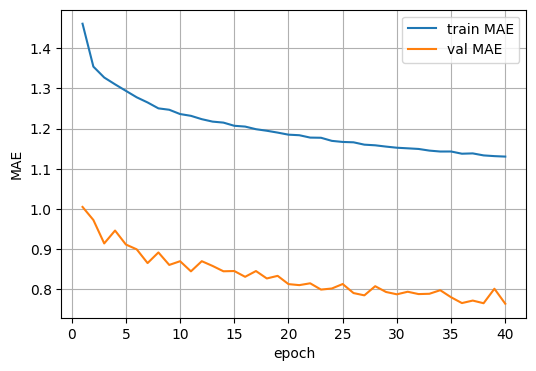

In [ ]:
# Purpose: training curves
import matplotlib.pyplot as plt
hist = model_best.history
plt.figure(figsize=(6,4))
plt.plot(hist["epoch"], hist["train_mae"], label="train MAE (plain)")
plt.plot(hist["epoch"], hist["val"],       label="val MAE (plain)")
# Optional: also see the optimized objective
plt.plot(hist["epoch"], hist["train_obj"], label="train objective", linestyle="--")
plt.xlabel("epoch"); plt.ylabel("MAE"); plt.legend(); plt.grid(True); plt.show()


#### HA vs linear regression vs best GNN

C:\Users\raf\AppData\Local\Temp\ipykernel_29056\1459699190.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  days = np.unique(day_idx[(cats[idx] == target_cat).values])


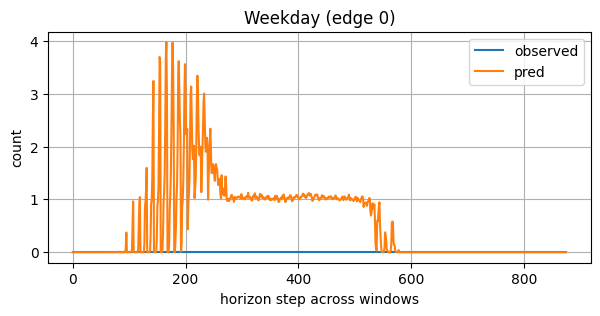

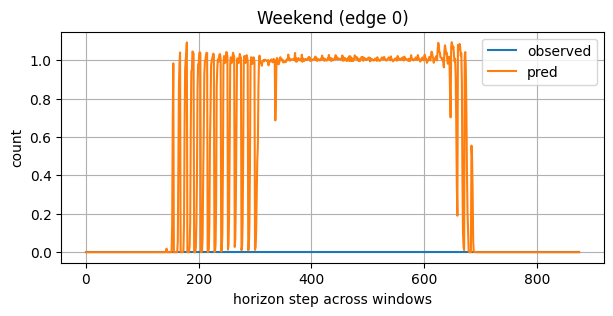

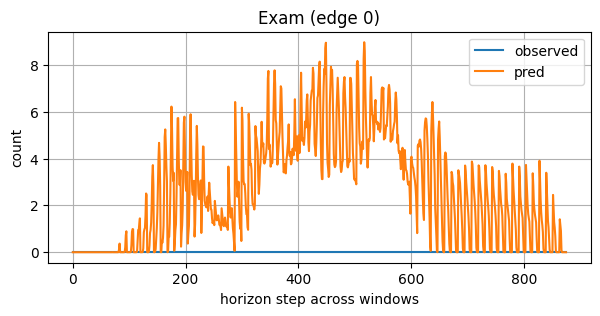

In [ ]:
# Purpose: pick random normal weekday, weekend, exam day from TEST and plot 3x (obs vs pred for one edge)
rng = np.random.RandomState(cfg.seed+1)
def sample_day_indices(mask_bool, cats, target_cat):
    idx = np.where(mask_bool)[0]
    day_idx = pd.DatetimeIndex(times[idx]).normalize()
    days = np.unique(day_idx[(cats[idx] == target_cat).values])
    if len(days)==0: return None
    d = days[rng.randint(0, len(days))]
    sel = np.where(day_idx == d)[0]
    return idx[sel]

def plot_obs_pred_for_day(day_idx, edge_id=0, title=""):
    if day_idx is None: 
        print("No day available:", title); 
        return
    # find all samples whose prediction window starts inside that day
    # we use the test dataset windows
    ds = loaders_final["test"].dataset
    xs, ys, yh = [], [], []
    for i in range(len(ds)):
        t0 = int(ds.starts[i]); t1 = t0 + cfg_best.H_in
        if t1 in day_idx:
            xs.append(ds[i]["x"].numpy())
            ys.append(ds[i]["y"].numpy())
            with torch.no_grad():
                yhat = model_best(torch.from_numpy(ds[i]["x"].numpy()[None]).to(cfg_best.device)).cpu().numpy()[0]
            yh.append(yhat)
    if len(xs)==0: 
        print("No windows on that day:", title)
        return
    Y = np.concatenate(ys, axis=0)[:, edge_id]
    YH = np.concatenate(yh, axis=0)[:, edge_id]
    plt.figure(figsize=(7,3))
    plt.plot(Y, label="observed")
    plt.plot(YH, label="pred")
    plt.title(title + f" (edge {edge_id})")
    plt.xlabel("horizon step across windows"); plt.ylabel("count"); plt.legend(); plt.grid(True); plt.show()

idx_weekday = sample_day_indices(masks_final["test"], cats, "weekday")
idx_weekend = sample_day_indices(masks_final["test"], cats, "weekend")
idx_exam    = sample_day_indices(masks_final["test"], cats, "exam")

plot_obs_pred_for_day(idx_weekday, edge_id=0, title="Weekday")
plot_obs_pred_for_day(idx_weekend, edge_id=0, title="Weekend")
plot_obs_pred_for_day(idx_exam,    edge_id=0, title="Exam")


#### Network at certain time

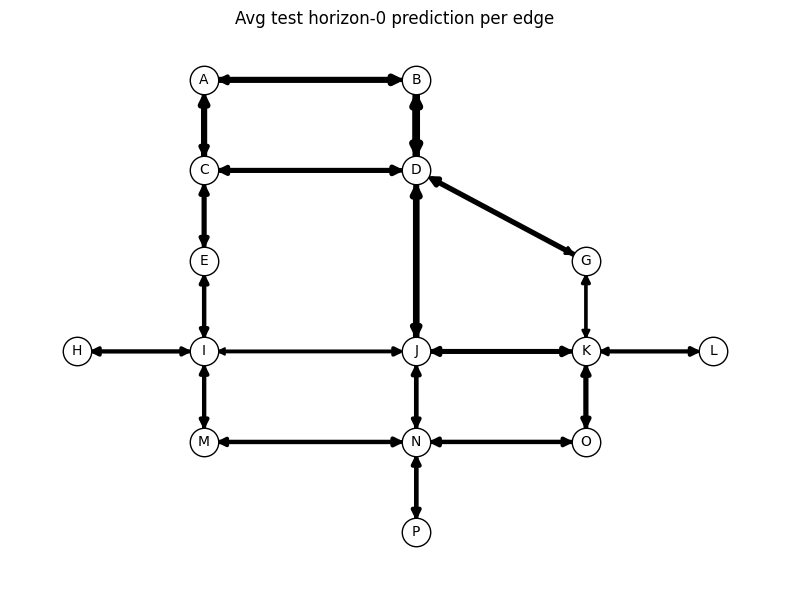

In [ ]:
# Purpose: network plot of average test horizon-0 predictions
# compute mean over test windows at horizon-0
ds = loaders_final["test"].dataset
preds = []
with torch.no_grad():
    for i in range(len(ds)):
        xb = ds[i]["x"].to(cfg_best.device)[None]
        yb = model_best(xb).cpu().numpy()[0]   # [H_out,E]
        preds.append(yb[0])                    # horizon-0
avg_edge = np.mean(np.stack(preds, axis=0), axis=0)  # [E]

edge_vals = {network_cfg.index_edge[i]: float(avg_edge[i]) for i in range(len(avg_edge))}
viz.draw_network_flows(edge_vals, network_cfg, title="Avg test horizon-0 prediction per edge")
